# ORAS5 Annual Cell-Year Classification

This notebook builds on the earlier ORAS5 classification test, but instead of using basin-mean monthly values, it works with **annual values at every grid cell**.

The aim is to see whether local ocean variables from ORAS5 can be used to distinguish between two climate regimes:

0 = before the threshold year  
1 = after the threshold year

The workflow is roughly:

1. Load and inspect the ORAS5 files
2. Build annual fields for each variable
3. Combine them into a single feature dataset
4. Convert the dataset into a machine-learning table
5. Train a classifier
6. Evaluate how well it separates the two regimes
7. Explore the data using correlations, distributions and trends

For now the analysis is restricted to a smaller North Atlantic region to keep things manageable.

## Imports

Import the packages needed for working with NetCDF files, data handling, plotting, and machine learning.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import re
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance

## Data Setup

Define the main settings used throughout the notebook:

• the directory containing the ORAS5 boxed files  
• the study region  
• the year used to split the two regimes  
• a folder where plots will be saved

A small helper function is also set up to keep track of plots produced in the notebook.

In [62]:
DATA_DIR = Path(r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\BOXED")

# Region
REGION = {
    "lat_min": 45,
    "lat_max": 65,
    "lon_min": -60,
    "lon_max": -20,
}

MID_YEAR = 1985
MAX_YEARS = None   # for fast testing

OUT_DIR = Path("meeting_outputs")
OUT_DIR.mkdir(exist_ok=True)

NOTEBOOK_NAME = "oras5_annual_cell_year_meeting_version"

PLOT_LOG = []

def save_and_register(fig, name, section, notes=""):
    path = OUT_DIR / f"{name}.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    PLOT_LOG.append({
        "notebook": NOTEBOOK_NAME,
        "section": section,
        "plot_name": name,
        "path": str(path),
        "notes": notes,
    })
    print(f"Saved: {path}")

## Variable Configuration

Define which variables will be used as features in the model.

For each variable I specify:

• the token used to identify its files  
• whether the annual value should be calculated as a mean or sum  
• whether depth averaging is needed

The variables included are:

SST  
salinity  
potential temperature  
net heat flux  
zonal current  
meridional current

In [13]:
FILE_RE = re.compile(r"ORAS5_(\d{4})_(\d{2})_(.+?)_boxed\.nc$")

VAR_META = {
    "sst": {
        "token": "sst",
        "agg": "mean",
        "depth_mode": None,
        "kind": "scalar",
    },
    "salinity": {
        "token": "so_salinity",
        "agg": "mean",
        "depth_mode": "0_100m",
        "kind": "scalar",
    },
    "thetao": {
        "token": "thetao",
        "agg": "mean",
        "depth_mode": "0_100m",
        "kind": "scalar",
    },
    "qnet": {
        "token": "heat",
        "agg": "sum",
        "depth_mode": None,
        "kind": "scalar",
    },
    "u_current": {
        "token": "u",
        "agg": "mean",
        "depth_mode": "0_100m",
        "kind": "scalar",
    },
    "v_current": {
        "token": "v",
        "agg": "mean",
        "depth_mode": "0_100m",
        "kind": "scalar",
    },
}

## Finding Files and Reading Dates

These helper functions locate files for each variable and extract the year and month from the filenames.

This information is later used to build the annual datasets.

In [14]:
def files_for_token(data_dir, token):
    all_nc = sorted(data_dir.rglob("*.nc"))
    out = [p for p in all_nc if FILE_RE.search(p.name) and token in p.name]
    return sorted(out)

def time_from_filename(path):
    m = FILE_RE.search(path.name)
    if m is None:
        raise ValueError(f"Filename does not match expected pattern: {path.name}")
    year = int(m.group(1))
    month = int(m.group(2))
    return pd.Timestamp(year=year, month=month, day=1)

## Quick File Check

Before doing anything heavy, check how many files are found for each variable token.

This just confirms that the filename matching is working correctly.

In [15]:
for name, meta in VAR_META.items():
    if meta["kind"] == "scalar":
        paths = files_for_token(DATA_DIR, meta["token"])
        print(f"{name:15s} -> {len(paths)} files using token '{meta['token']}'")
        if len(paths) > 0:
            print("   first:", paths[0].name)
    else:
        upaths = files_for_token(DATA_DIR, meta["u_token"])
        vpaths = files_for_token(DATA_DIR, meta["v_token"])
        print(f"{name:15s} -> {len(upaths)} u-files ('{meta['u_token']}'), {len(vpaths)} v-files ('{meta['v_token']}')")
        if len(upaths) > 0:
            print("   u first:", upaths[0].name)
        if len(vpaths) > 0:
            print("   v first:", vpaths[0].name)

sst             -> 606 files using token 'sst'
   first: ORAS5_1958_01_sst_boxed.nc
salinity        -> 594 files using token 'so_salinity'
   first: ORAS5_1958_01_so_salinity_boxed.nc
thetao          -> 598 files using token 'thetao'
   first: ORAS5_1958_01_thetao_potential_temperature_boxed.nc
qnet            -> 604 files using token 'heat'
   first: ORAS5_1958_01_net_downward_heat_flux_boxed.nc
u_current       -> 2187 files using token 'u'
   first: ORAS5_1958_01_net_downward_heat_flux_boxed.nc
v_current       -> 1006 files using token 'v'
   first: ORAS5_1958_01_meridional_velocity_boxed.nc


## Inspecting Example Files

Look at one example file for each variable to see:

• variable names  
• coordinate names  
• dataset dimensions

ORAS5 files sometimes use slightly different dimension names, so this step helps avoid problems later.

In [16]:
def inspect_file(path):
    with xr.open_dataset(path) as ds:
        print(f"\nFILE: {path.name}")
        print("dims:", dict(ds.dims))
        print("coords:", list(ds.coords))
        print("data_vars:", list(ds.data_vars))
        for name in list(ds.data_vars)[:5]:
            da = ds[name]
            print(f"  {name}: dims={da.dims}, shape={da.shape}")

for name, meta in VAR_META.items():
    if meta["kind"] == "scalar":
        paths = files_for_token(DATA_DIR, meta["token"])
        if paths:
            inspect_file(paths[0])
    else:
        upaths = files_for_token(DATA_DIR, meta["u_token"])
        vpaths = files_for_token(DATA_DIR, meta["v_token"])
        if upaths:
            inspect_file(upaths[0])
        if vpaths:
            inspect_file(vpaths[0])


FILE: ORAS5_1958_01_sst_boxed.nc
dims: {'time_counter': 1, 'y': 522, 'x': 363}
coords: ['nav_lat', 'nav_lon', 'time_counter']
data_vars: ['sosstsst']
  sosstsst: dims=('time_counter', 'y', 'x'), shape=(1, 522, 363)

FILE: ORAS5_1958_01_so_salinity_boxed.nc
dims: {'time_counter': 1, 'deptht': 75, 'y': 522, 'x': 363}
coords: ['deptht', 'nav_lat', 'nav_lon', 'time_counter']
data_vars: ['vosaline']
  vosaline: dims=('time_counter', 'deptht', 'y', 'x'), shape=(1, 75, 522, 363)

FILE: ORAS5_1958_01_thetao_potential_temperature_boxed.nc
dims: {'time_counter': 1, 'deptht': 75, 'y': 522, 'x': 363}
coords: ['deptht', 'nav_lat', 'nav_lon', 'time_counter']
data_vars: ['votemper']
  votemper: dims=('time_counter', 'deptht', 'y', 'x'), shape=(1, 75, 522, 363)

FILE: ORAS5_1958_01_net_downward_heat_flux_boxed.nc
dims: {'time_counter': 1, 'y': 522, 'x': 363}
coords: ['nav_lat', 'nav_lon', 'time_counter']
data_vars: ['sohefldo']
  sohefldo: dims=('time_counter', 'y', 'x'), shape=(1, 522, 363)

FILE: O

## Helper Functions

Define several small functions used later when building the datasets.

These handle things like:

• identifying the main variable in a file  
• finding coordinate names  
• subsetting the region  
• handling depth dimensions  
• standardising time coordinates

In [27]:
def find_main_var(ds):
    ignore = {
        "time", "time_counter", "valid_time", "nav_time",
        "lat", "lon", "latitude", "longitude", "nav_lat", "nav_lon",
        "depth", "deptht", "depthu", "depthv", "nav_lev"
    }
    candidates = [k for k in ds.data_vars if k not in ignore]
    if len(candidates) == 0:
        raise ValueError(f"No usable data variable found. data_vars={list(ds.data_vars)}")
    return candidates[0]

def find_coord_name(ds, options):
    for name in options:
        if name in ds.coords or name in ds.variables:
            return name
    return None

def normalise_longitude(lon):
    return xr.where(lon > 180, lon - 360, lon)

def subset_region(ds, region):
    lat_name = find_coord_name(ds, ["lat", "latitude", "nav_lat"])
    lon_name = find_coord_name(ds, ["lon", "longitude", "nav_lon"])

    if lat_name is None or lon_name is None:
        print("Warning: could not find lat/lon coords; skipping regional subset")
        return ds

    lat = ds[lat_name]
    lon = ds[lon_name]
    lon = normalise_longitude(lon)

    if lon_name in ds.coords:
        ds = ds.assign_coords({lon_name: lon})

    mask = (
        (lat >= region["lat_min"]) & (lat <= region["lat_max"]) &
        (lon >= region["lon_min"]) & (lon <= region["lon_max"])
    )
    return ds.where(mask, drop=True)

def depth_reduce_if_needed(da, ds, depth_mode):
    if depth_mode is None:
        return da

    for zname in ["depth", "deptht", "depthu", "depthv", "nav_lev"]:
        if zname in da.dims:
            # Try to get the depth coordinate from the DataArray first
            if zname in da.coords:
                z = da[zname]
            elif zname in ds.coords:
                z = ds[zname]
            elif zname in ds.variables:
                z = ds[zname]
            else:
                # if the dim exists but no coord is found then fallback to index positions
                z = xr.DataArray(np.arange(da.sizes[zname]), dims=[zname], coords={zname: np.arange(da.sizes[zname])})

            if depth_mode == "0_100m":
                da = da.where((z >= 0) & (z <= 100), drop=True).mean(dim=zname)
                return da

    return da

def rename_time_dim_if_needed(da):
    for old in ["time_counter", "valid_time", "nav_time"]:
        if old in da.dims:
            return da.rename({old: "time"})
    return da

def add_time_coord(da, tstamp):
    if "time" in da.dims:
        da = da.assign_coords(time=[np.datetime64(tstamp)])
    else:
        da = da.expand_dims(time=[np.datetime64(tstamp)])
    return da

def get_spatial_dims(da):
    return [d for d in da.dims if d != "time"]

## Building Annual Fields

This function creates an annual gridded field for a given variable.

For each monthly file it:

1. Opens the dataset  
2. Extracts the variable  
3. Applies depth averaging if required  
4. Subsets the study region  
5. Adds a time coordinate  

The monthly data are then combined and aggregated into **annual values**.

In [34]:
def build_annual_scalar_field(data_dir, var_name, meta, region, max_years=None):
    paths = files_for_token(data_dir, meta["token"])
    if len(paths) == 0:
        raise FileNotFoundError(f"No files found for {var_name} with token '{meta['token']}'")

    if max_years is not None:
        years_seen = sorted({time_from_filename(p).year for p in paths})[:max_years]
        paths = [p for p in paths if time_from_filename(p).year in years_seen]

    monthly_arrays = []

    for i, p in enumerate(paths, start=1):
        if i == 1 or i % 25 == 0 or i == len(paths):
            print(f"[{var_name}] {i}/{len(paths)} {p.name}")

        tstamp = time_from_filename(p)

        with xr.open_dataset(p) as ds:
            ds = subset_region(ds, region)

            vname = find_main_var(ds)
            da = ds[vname]

            da = depth_reduce_if_needed(da, ds, meta["depth_mode"])
            da = rename_time_dim_if_needed(da)

            if "time" in da.dims and da.sizes["time"] == 1:
                da = da.isel(time=0, drop=True)

            da = da.squeeze(drop=True)

            monthly_arrays.append((tstamp, da.load()))

    if len(monthly_arrays) == 0:
        raise ValueError(f"No monthly arrays built for {var_name}")

    # Keep only dims common to every monthly field
    common_dims = list(monthly_arrays[0][1].dims)
    for _, da in monthly_arrays[1:]:
        common_dims = [d for d in common_dims if d in da.dims]

    if len(common_dims) == 0:
        raise ValueError(f"No common dims found across monthly arrays for {var_name}")

    cleaned_arrays = []
    for tstamp, da in monthly_arrays:
        extra_dims = [d for d in da.dims if d not in common_dims]
        for d in extra_dims:
            if da.sizes[d] == 1:
                da = da.isel({d: 0}, drop=True)
            else:
                raise ValueError(
                    f"{var_name} file at {tstamp} has non-singleton extra dim '{d}' "
                    f"with size {da.sizes[d]} and dims {da.dims}"
                )

        da = da.squeeze(drop=True)
        da = da.transpose(*common_dims, ...)
        cleaned_arrays.append((tstamp, da))

    # Trim all months to same minimum size along shared dims
    min_sizes = {
        d: min(da.sizes[d] for _, da in cleaned_arrays)
        for d in common_dims
    }

    fixed_arrays = []
    for tstamp, da in cleaned_arrays:
        indexers = {d: slice(0, min_sizes[d]) for d in common_dims}
        da = da.isel(**indexers)

        # Replace shared coords with integers
        da = da.assign_coords({d: np.arange(min_sizes[d]) for d in common_dims})

        # Drop leftover coords
        drop_coords = [c for c in da.coords if c not in common_dims]
        if len(drop_coords) > 0:
            da = da.drop_vars(drop_coords, errors="ignore")

        da = add_time_coord(da, tstamp)
        fixed_arrays.append(da)

    # for concat
    da_all = xr.concat(
        fixed_arrays,
        dim="time",
        coords="minimal",
        compat="override",
        join="override"
    )

    if meta["agg"] == "mean":
        annual = da_all.groupby("time.year").mean("time")
    elif meta["agg"] == "sum":
        annual = da_all.groupby("time.year").sum("time")
    else:
        raise ValueError(f"Unknown aggregation: {meta['agg']}")

    annual.name = var_name
    return annual

## Vector Variables

A second function is included for combining vector components into speeds.

In this notebook the zonal and meridional currents are kept as separate features, but the function is left here for flexibility.

In [35]:
def build_annual_vector_speed_field(data_dir, var_name, meta, region, max_years=None):
    upaths = files_for_token(data_dir, meta["u_token"])
    vpaths = files_for_token(data_dir, meta["v_token"])

    if len(upaths) == 0 or len(vpaths) == 0:
        raise FileNotFoundError(f"Missing u/v files for {var_name}")

    u_map = {time_from_filename(p): p for p in upaths}
    v_map = {time_from_filename(p): p for p in vpaths}
    common_times = sorted(set(u_map).intersection(v_map))

    if max_years is not None:
        years_seen = sorted({t.year for t in common_times})[:max_years]
        common_times = [t for t in common_times if t.year in years_seen]

    monthly_speed = []

    for i, tstamp in enumerate(common_times, start=1):
        if i == 1 or i % 25 == 0 or i == len(common_times):
            print(f"[{var_name}] {i}/{len(common_times)} {tstamp:%Y-%m}")

        with xr.open_dataset(u_map[tstamp]) as dsu, xr.open_dataset(v_map[tstamp]) as dsv:
            dsu = subset_region(dsu, region)
            dsv = subset_region(dsv, region)

            uname = find_main_var(dsu)
            vname = find_main_var(dsv)

            u = depth_reduce_if_needed(dsu[uname], dsu, meta["depth_mode"])
            v = depth_reduce_if_needed(dsv[vname], dsv, meta["depth_mode"])

            u = rename_time_dim_if_needed(u)
            v = rename_time_dim_if_needed(v)

            u, v = xr.align(u, v, join="inner")

            speed = np.sqrt(u**2 + v**2)
            speed = add_time_coord(speed, tstamp)
            monthly_speed.append(speed.load())

    if len(monthly_speed) == 0:
        raise ValueError(f"No monthly speed arrays built for {var_name}")

    da_all = xr.concat(monthly_speed, dim="time")

    if meta["agg"] == "mean":
        annual = da_all.groupby("time.year").mean("time")
    elif meta["agg"] == "sum":
        annual = da_all.groupby("time.year").sum("time")
    else:
        raise ValueError(f"Unknown aggregation: {meta['agg']}")

    annual.name = var_name
    return annual

## Building the Annual Feature Fields

Loop through the selected variables and build the annual field for each one.

To make debugging easier, the notebook starts with the meridional current before processing the remaining variables.

In [36]:
annual_fields = {}

# Force v_current to run first (for debugging)
build_order = []
if "v_current" in VAR_META:
    build_order.append("v_current")

# add everything else in original order (excluding v_current)
build_order += [name for name in VAR_META.keys() if name != "v_current"]

print("Build order:", build_order)

for var_name in build_order:
    meta = VAR_META[var_name]
    print(f"\n=== Building {var_name} ===")
    annual_da = build_annual_scalar_field(
        DATA_DIR, var_name, meta, REGION, max_years=MAX_YEARS
    )
    annual_fields[var_name] = annual_da
    print(var_name, annual_da.shape, annual_da.dims)

Build order: ['v_current', 'sst', 'salinity', 'thetao', 'qnet', 'u_current']

=== Building v_current ===
[v_current] 1/1007 ORAS5_1958_01_meridional_velocity_boxed.nc
[v_current] 25/1007 ORAS5_1959_11_v_meridional_boxed.nc
[v_current] 50/1007 ORAS5_1961_12_v_meridional_boxed.nc
[v_current] 75/1007 ORAS5_1964_01_v_meridional_boxed.nc
[v_current] 100/1007 ORAS5_1966_02_v_meridional_boxed.nc
[v_current] 125/1007 ORAS5_1968_03_v_meridional_boxed.nc
[v_current] 150/1007 ORAS5_1970_04_v_meridional_boxed.nc
[v_current] 175/1007 ORAS5_1972_05_v_meridional_boxed.nc
[v_current] 200/1007 ORAS5_1974_06_v_meridional_boxed.nc
[v_current] 225/1007 ORAS5_1975_10_v_meridional_boxed.nc
[v_current] 250/1007 ORAS5_1976_10_v_rotated_boxed.nc
[v_current] 275/1007 ORAS5_1977_11_v_meridional_boxed.nc
[v_current] 300/1007 ORAS5_1978_11_v_rotated_boxed.nc
[v_current] 325/1007 ORAS5_1979_12_v_meridional_boxed.nc
[v_current] 350/1007 ORAS5_1980_12_v_rotated_boxed.nc
[v_current] 375/1007 ORAS5_1982_01_v_meridional

## Combining the Variables

The annual fields are combined into a single xarray dataset containing all features on the same grid.

This dataset can also be saved so that the expensive preprocessing step does not need to be repeated.

In [63]:
ds_features = xr.Dataset(annual_fields)
print(ds_features)

feature_nc = OUT_DIR / "annual_feature_fields.nc"
ds_features.to_netcdf(feature_nc)

<xarray.Dataset> Size: 33MB
Dimensions:    (y: 142, x: 158, year: 61)
Coordinates:
  * y          (y) int32 568B 0 1 2 3 4 5 6 7 ... 135 136 137 138 139 140 141
  * x          (x) int32 632B 0 1 2 3 4 5 6 7 ... 151 152 153 154 155 156 157
  * year       (year) int64 488B 1958 1959 1960 1961 ... 2015 2016 2017 2018
Data variables:
    v_current  (year, y, x) float32 5MB nan nan nan nan nan ... nan nan nan nan
    sst        (year, y, x) float32 5MB nan nan nan nan nan ... nan nan nan nan
    salinity   (year, y, x) float32 5MB nan nan nan nan nan ... nan nan nan nan
    thetao     (year, y, x) float32 5MB nan nan nan nan nan ... nan nan nan nan
    qnet       (year, y, x) float32 5MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    u_current  (year, y, x) float32 5MB nan nan nan nan nan ... nan nan nan nan


## Building the Feature Table

Convert the gridded dataset into a table that can be used by scikit-learn.

In this format:

Rows = grid cell in a particular year  
Columns = feature values for that cell and year

This is different from the earlier notebook where each row represented a basin-mean month.

In [64]:
spatial_dims = [d for d in ds_features[list(ds_features.data_vars)[0]].dims if d != "year"]
print("Spatial dims:", spatial_dims)

tmp = ds_features.reset_coords(drop=True)

stacked = tmp.stack(cell=spatial_dims)

df = pd.DataFrame({
    "year": stacked["year"].values.repeat(stacked.sizes["cell"]),
    "cell": np.tile(np.arange(stacked.sizes["cell"]), stacked.sizes["year"]),
})

for var in list(tmp.data_vars):
    df[var] = stacked[var].values.reshape(-1)

feature_cols = list(tmp.data_vars)
df = df.dropna(subset=feature_cols).reset_index(drop=True)

print(df.shape)
display(df.head())

Spatial dims: ['y', 'x']
(980804, 8)


,year,cell,v_current,sst,salinity,thetao,qnet,u_current
0,1958,81,0.095932,15.993309,35.668362,15.676735,-945.810303,-20.994547
1,1958,82,0.137022,15.989177,35.704491,15.686134,-809.714600,-17.208454
2,1958,83,0.173239,15.952010,35.711464,15.652306,-612.035950,-11.722572
3,1958,84,0.207334,15.883855,35.697231,15.586292,-344.052612,-4.293533
4,1958,85,0.223805,15.805103,35.669437,15.498050,-63.650318,3.469636


## Defining the Target Variable

I define a binary classification target based on year:

- 0 = before the threshold year
- 1 = from the threshold year onward

I also print the class balance to check how evenly the two regimes are represented in the final cell-year table.

In [80]:
df["target"] = (df["year"] >= MID_YEAR).astype(int)

keep_cols = ["year", "cell"] + feature_cols + ["target"]
for c in df.columns:
    if c in keep_cols:
        continue
    # keep coordinate columns if useful
    if c.lower() in ["lat", "lon", "latitude", "longitude", "nav_lat", "nav_lon", "x", "y"]:
        keep_cols.append(c)

df = df[keep_cols]

print("Class balance:")
print(df["target"].value_counts())
display(df.head())

Class balance:
target
1    517278
0    463526
Name: count, dtype: int64


,year,cell,v_current,sst,salinity,thetao,qnet,u_current,target
0,1958,81,0.095932,15.993309,35.668362,15.676735,-945.810303,-20.994547,0
1,1958,82,0.137022,15.989177,35.704491,15.686134,-809.714600,-17.208454,0
2,1958,83,0.173239,15.952010,35.711464,15.652306,-612.035950,-11.722572,0
3,1958,84,0.207334,15.883855,35.697231,15.586292,-344.052612,-4.293533,0
4,1958,85,0.223805,15.805103,35.669437,15.498050,-63.650318,3.469636,0


## Train / Test Split

Split the dataset into training and testing sets.

A stratified split is used so that the class proportions remain roughly the same in both sets.

In [66]:
model_features = feature_cols

X = df[model_features].copy()
y = df["target"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=1,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train balance:", y_train.value_counts().to_dict())
print("Test balance:", y_test.value_counts().to_dict())

Train shape: (784643, 6)
Test shape: (196161, 6)
Train balance: {1: 413822, 0: 370821}
Test balance: {1: 103456, 0: 92705}


## Training the Model

Train a histogram gradient boosting classifier using the annual features.

Boosted tree models are well suited to large tabular datasets and can capture nonlinear relationships between variables.

In [67]:
model = HistGradientBoostingClassifier(
    max_depth=6,
    learning_rate=0.05,
    max_iter=200,
    random_state=1
)

model.fit(X_train, y_train)
print("Model trained.")

Model trained.


## Model Evaluation

Evaluate the classifier using:

• the classification report  
• the confusion matrix  
• the ROC curve and AUC score

These metrics show how well the model separates the two regimes.

              precision    recall  f1-score   support

           0       0.83      0.74      0.78     92705
           1       0.78      0.86      0.82    103456

    accuracy                           0.80    196161
   macro avg       0.80      0.80      0.80    196161
weighted avg       0.80      0.80      0.80    196161

Confusion matrix:
 [[68184 24521]
 [14381 89075]]


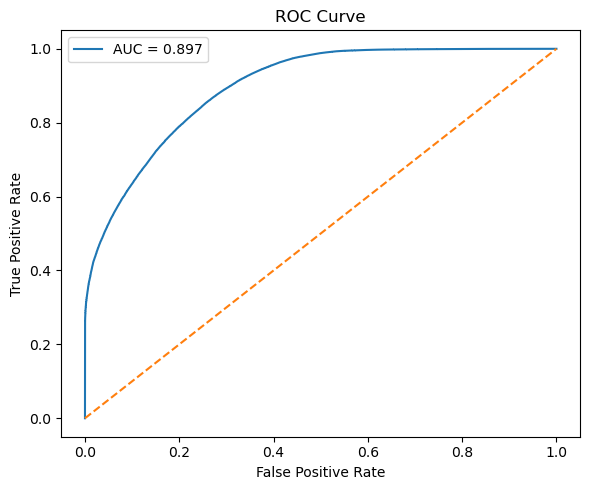

In [68]:
from sklearn.metrics import roc_curve, auc

# Predictions
pred = model.predict(X_test)
proba = model.predict_proba(X_test)[:, 1]

# Metrics
print(classification_report(y_test, pred, zero_division=0))
print("Confusion matrix:\n", confusion_matrix(y_test, pred))

# ROC
fpr, tpr, _ = roc_curve(y_test, proba)
roc_auc = auc(fpr, tpr)

fig = plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.tight_layout()

plt.show()

## Feature Importance

Permutation importance is used to see which variables the model relies on most strongly.

Each feature is shuffled and the drop in model performance is measured.

In [69]:
perm = permutation_importance(
    model, X_test, y_test,
    n_repeats=5,
    random_state=1,
    scoring="roc_auc"
)

imp_df = pd.DataFrame({
    "feature": model_features,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=True)

display(imp_df.sort_values("importance_mean", ascending=False))

,feature,importance_mean,importance_std
4,qnet,0.385861,0.001395
5,u_current,0.316595,0.000707
1,sst,0.118044,0.000477
3,thetao,0.094075,0.000584
2,salinity,0.090285,0.000626
0,v_current,0.006557,0.000125


## Visualising Feature Importance

Plot the permutation importances as a bar chart to show which variables contribute most to the classification.

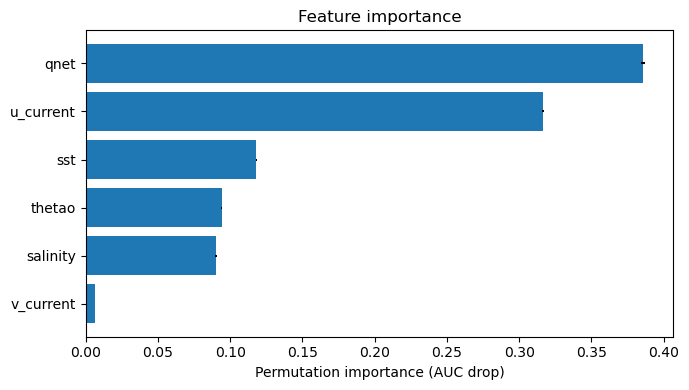

In [70]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(imp_df["feature"], imp_df["importance_mean"], xerr=imp_df["importance_std"])
ax.set_xlabel("Permutation importance (AUC drop)")
ax.set_title("Feature importance")
plt.tight_layout()
plt.show()

## Correlation Matrix

Calculate the Pearson correlation matrix between the input variables.

This helps identify whether some predictors contain similar information.

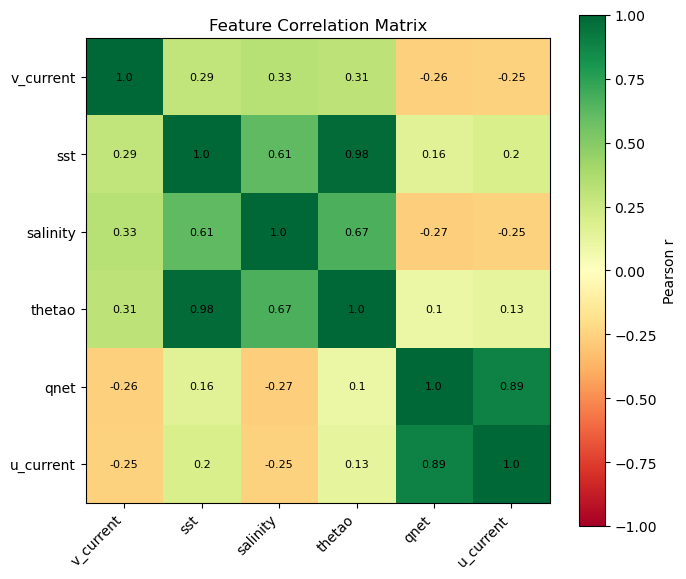

In [71]:
corr = X.corr().round(2)

fig = plt.figure(figsize=(7,6))

im = plt.imshow(corr, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(im, label="Pearson r")

labels = corr.columns
plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
plt.yticks(range(len(labels)), labels)

for i in range(len(corr)):
    for j in range(len(corr)):
        plt.text(j, i, corr.iloc[i, j],
                 ha="center", va="center", fontsize=8)

plt.title("Feature Correlation Matrix")
plt.tight_layout()

plt.show()

## Feature Distributions

Plot histograms of each feature before and after the threshold year.

This gives a simple view of how the two regimes differ in each variable individually.

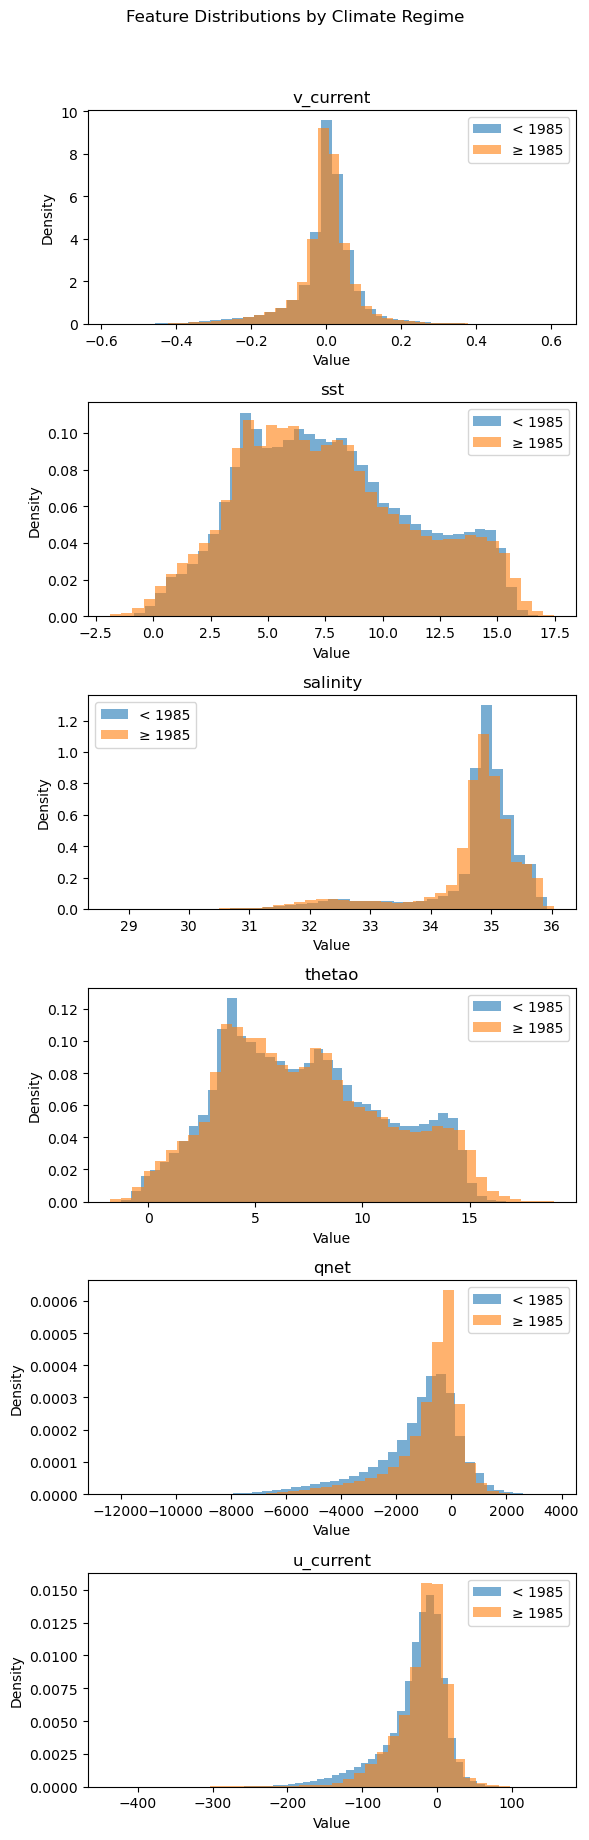

In [72]:
features = feature_cols
n = len(features)

fig, axes = plt.subplots(n, 1, figsize=(6, 3*n), sharex=False)

if n == 1:
    axes = [axes]

for i, f in enumerate(features):

    axes[i].hist(
        df[df["target"] == 0][f],
        bins=40,
        alpha=0.6,
        label=f"< {MID_YEAR}",
        density=True
    )

    axes[i].hist(
        df[df["target"] == 1][f],
        bins=40,
        alpha=0.6,
        label=f"≥ {MID_YEAR}",
        density=True
    )

    axes[i].set_title(f)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Density")
    axes[i].legend()

plt.suptitle("Feature Distributions by Climate Regime", y=1.02)
plt.tight_layout()

plt.show()

## Regional Mean Trends

Calculate the annual regional mean of each feature and plot them as time series.

A linear trend is fitted to each variable and the uncertainty on the trend is shown with a 1-sigma band.

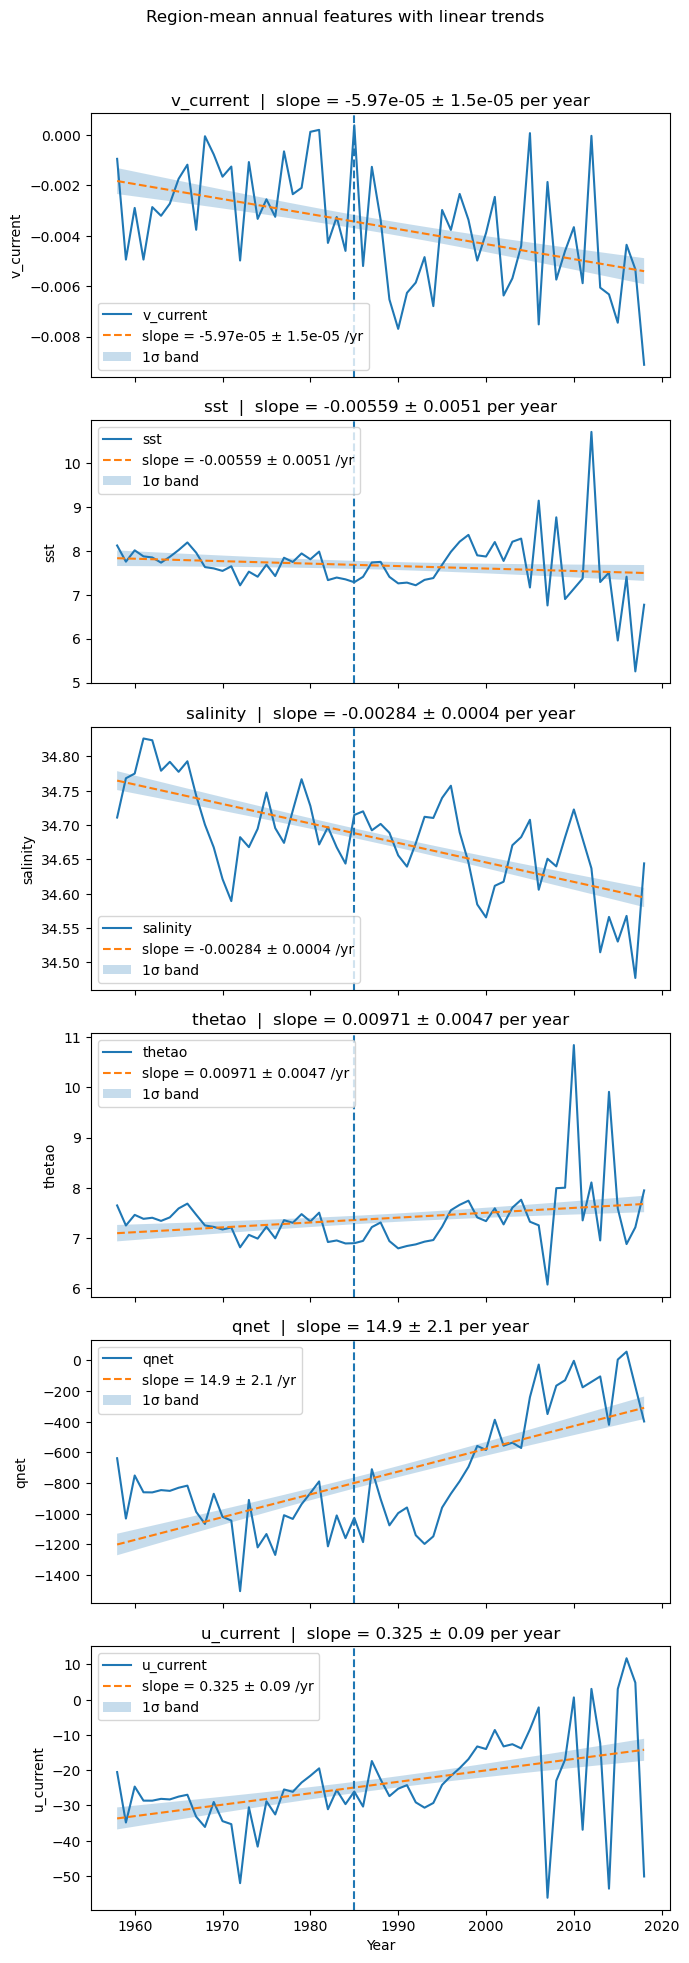

In [75]:
from scipy.stats import linregress
import numpy as np

annual_mean_df = ds_features.mean(dim=spatial_dims).to_dataframe().reset_index()

features_to_plot = [col for col in feature_cols if col in annual_mean_df.columns]
n = len(features_to_plot)

fig, axes = plt.subplots(n, 1, figsize=(7, 3.2*n), sharex=True)

if n == 1:
    axes = [axes]

for ax, col in zip(axes, features_to_plot):

    x = annual_mean_df["year"].values.astype(float)
    y = annual_mean_df[col].values.astype(float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    res = linregress(x, y)

    y_fit = res.intercept + res.slope * x

    # Residual standard error
    residuals = y - y_fit
    npts = len(x)
    s = np.sqrt(np.sum(residuals**2) / (npts - 2))

    x_mean = np.mean(x)
    Sxx = np.sum((x - x_mean)**2)

    sigma_y = s * np.sqrt(1/npts + (x - x_mean)**2 / Sxx)

    ax.plot(x, y, label=col)
    ax.plot(x, y_fit, "--", label=f"slope = {res.slope:.3g} ± {res.stderr:.2g} /yr")

    ax.fill_between(
        x,
        y_fit - sigma_y,
        y_fit + sigma_y,
        alpha=0.25,
        label="1σ band"
    )

    ax.axvline(MID_YEAR, linestyle="--")

    ax.set_title(f"{col}  |  slope = {res.slope:.3g} ± {res.stderr:.2g} per year")
    ax.set_ylabel(col)
    ax.legend()

axes[-1].set_xlabel("Year")

plt.suptitle("Region-mean annual features with linear trends", y=1.02)
plt.tight_layout()

plt.show()

## Summary

This notebook tests whether annual ocean variables from ORAS5 can distinguish between two climate regimes.

Instead of basin averages, the model uses **every grid cell**, allowing it to pick up both spatial and multivariate patterns in the data.